In [128]:
import numpy as np 
import pandas as pd 


In [129]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [130]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [131]:
df.shape

(5572, 5)

# DATA CLEANING

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [133]:
df.drop(columns=['Unnamed: 2' , 'Unnamed: 3' , 'Unnamed: 4'], inplace=True )

# droping Last 3 column Bcoz it has large numbers of null values 

In [134]:
df.sample(5)

,v1,v2
1174,ham,Yay! You better not have told that to 5 other ...
2546,ham,Company is very good.environment is terrific a...
5264,ham,"Storming msg: Wen u lift d phne, u say \HELLO\..."
5493,ham,I think if he rule tamilnadu..then its very to...
4063,ham,Prof: you have passed in all the papers in thi...


In [135]:
# rename the column 
df.rename(columns={'v1' : 'target' , 'v2' : 'text'}, inplace=True)
df.sample(5)

,target,text
2064,ham,Pass dis to all ur contacts n see wat u get! R...
3077,ham,Okay but i thought you were the expert
80,ham,"Sorry, I'll call later"
3127,ham,would u fuckin believe it they didnt know i ha...
2036,ham,You can jot down things you want to remember l...


 # Label Encoding

In [136]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [137]:
# ham as 0 , Spam as 1
df['target'] = encoder.fit_transform(df['target'])

In [138]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [139]:
# check missing valueabs

df.isnull().sum()

target    0
text      0
dtype: int64

In [140]:
df.duplicated().sum()

np.int64(403)

In [141]:
# removing duplicates 
df = df.drop_duplicates(keep='first')

In [142]:
df.duplicated().sum()

np.int64(0)

In [143]:
df.shape

(5169, 2)

 # EDA

In [144]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

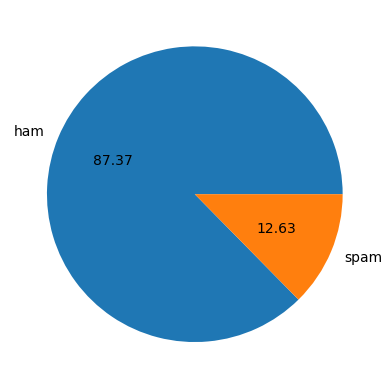

In [145]:
import matplotlib.pyplot as plt 
plt.pie(df['target'].value_counts() , labels=['ham' , 'spam'], autopct="%0.2f")
plt.show()
# craeting pie graph to see percentage of Ham and Spam
# From pie plot we can see Data is Imbalance

In [146]:
import nltk

In [147]:
!pip install nltk

In [148]:

nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/satyamkumar/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/satyamkumar/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [149]:
# Numbers of text 
df['num_characters'] =df['text'].apply(len)

In [150]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [151]:
# the numbers of word
df['text'].apply(lambda x:nltk.word_tokenize(x))

0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568     [Will, Ì_, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: text, Length: 5169, dtype: object

In [152]:
# using ken function t finf len of words 
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [153]:
# couting the number of senetces 
df['text'].apply(lambda x:nltk.sent_tokenize(x))

0       [Go until jurong point, crazy.., Available onl...
1                        [Ok lar..., Joking wif u oni...]
2       [Free entry in 2 a wkly comp to win FA Cup fin...
3       [U dun say so early hor... U c already then sa...
4       [Nah I don't think he goes to usf, he lives ar...
                              ...                        
5567    [This is the 2nd time we have tried 2 contact ...
5568              [Will Ì_ b going to esplanade fr home?]
5569    [Pity, * was in mood for that., So...any other...
5570    [The guy did some bitching but I acted like i'...
5571                        [Rofl., Its true to its name]
Name: text, Length: 5169, dtype: object

In [154]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [155]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,24
1,0,Ok lar... Joking wif u oni...,29,8,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,37
3,0,U dun say so early hor... U c already then say...,49,13,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,15


In [156]:
df[['num_characters' , 'num_words' , 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,18.455794
std,58.236293,13.324758,13.324758
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,9.000000
50%,60.000000,15.000000,15.000000
75%,117.000000,26.000000,26.000000
max,910.000000,220.000000,220.000000


In [157]:

# Ham Messages
df[df['target'] == 0][['num_characters' , 'num_words' , 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,17.123782
std,56.358207,13.493970,13.493970
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,8.000000
50%,52.000000,13.000000,13.000000
75%,90.000000,22.000000,22.000000
max,910.000000,220.000000,220.000000


In [158]:
# for Spam message
df[df['target'] == 1][['num_characters' , 'num_words' , 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,27.667688
std,30.137753,7.008418,7.008418
min,13.000000,2.000000,2.000000
25%,132.000000,25.000000,25.000000
50%,149.000000,29.000000,29.000000
75%,157.000000,32.000000,32.000000
max,224.000000,46.000000,46.000000


# plotting historam for ham and spam

In [159]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

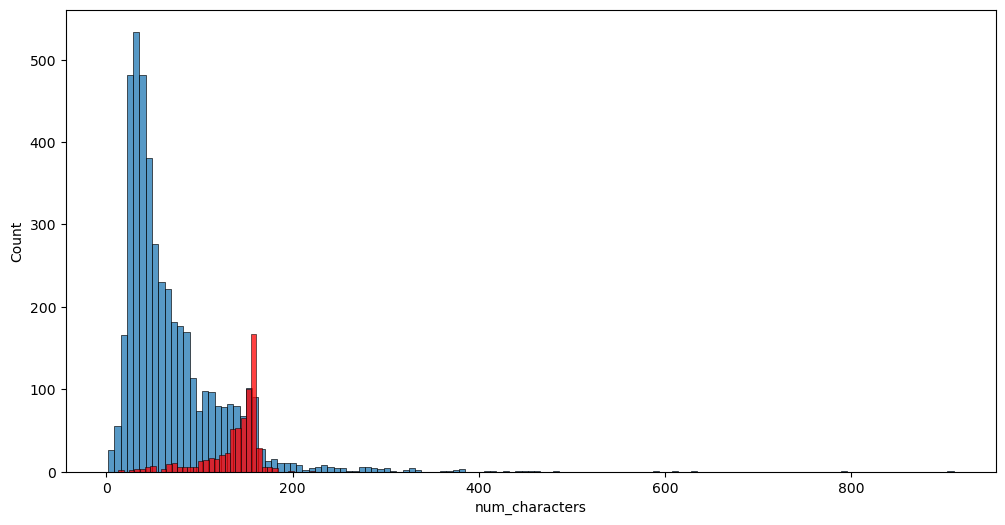

In [160]:
# 
plt.figure(figsize=(12,6)) 
sns.histplot(df[df['target'] == 0 ]['num_characters']) # for Ham messages
sns.histplot(df[df['target'] == 1 ]['num_characters'] , color='red') # for Spam messages


<Axes: xlabel='num_words', ylabel='Count'>

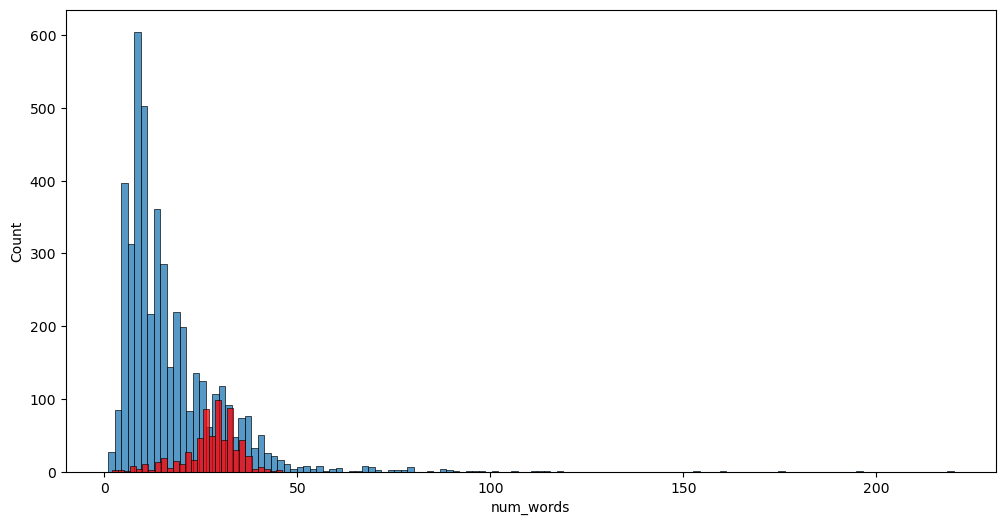

In [161]:
plt.figure(figsize=(12,6)) 
sns.histplot(df[df['target'] == 0 ]['num_words']) # for Ham messages
sns.histplot(df[df['target'] == 1 ]['num_words'] , color='red') # for Spam messages


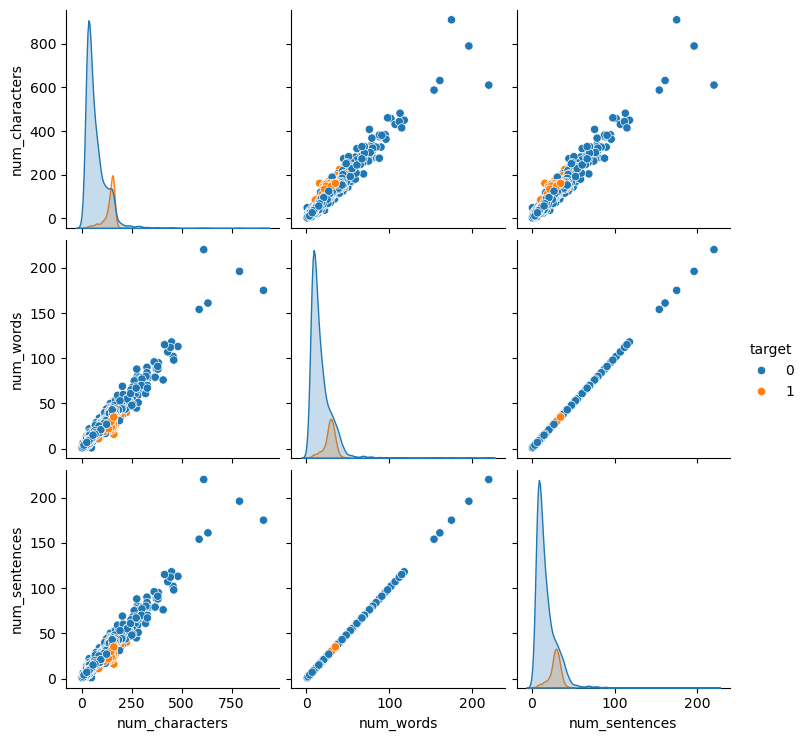

In [162]:
 # relation Between columns 
sns.pairplot(df , hue='target')

In [163]:
df.corr(numeric_only=True)

,target,num_characters,num_words,num_sentences
target,1.000000,0.384717,0.262912,0.262912
num_characters,0.384717,1.000000,0.965760,0.965760
num_words,0.262912,0.965760,1.000000,1.000000
num_sentences,0.262912,0.965760,1.000000,1.000000


<Axes: >

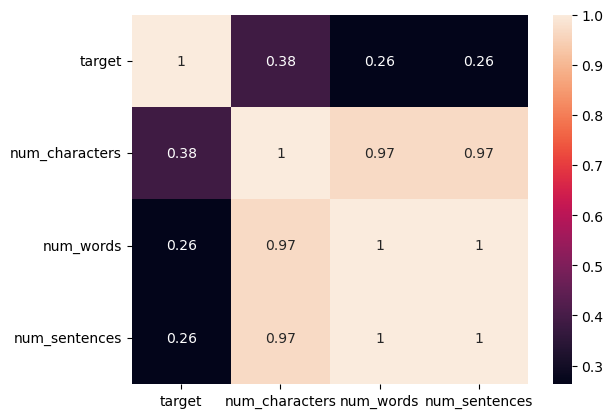

In [164]:
# relation with heeatmap 
sns.heatmap(df.corr(numeric_only=True), annot=True)

# annottaion show the number inside the box

# DATA PREPROCESSING
 (Lower Case)
 (Tokenization)
 (Removing stop words and Puntuation)
 (Remove Special Characters)
 (Stemming)
 

In [165]:
from nltk.stem.porter import PorterStemmer # Stemaing menas verb in first form 
ps = PorterStemmer()


In [166]:

def transform_text(text): 
    text = text.lower() # for Lower case the Text
    text = nltk.word_tokenize(text) # for Create Token in The list from the text 
    y = []

    
    for i in text: # for removing special character 
        if i.isalnum(): 
            y.append(i)

    text = y[:] # cloning the text 
    y.clear()

    for i in text: # removing stopwords with punctuation 
        if i not in stopwords.words('english') and i not in string.punctuation: 
            y.append(i)

    text = y[:] # Stemming Part
    y.clear()

    for i in text: 
         y.append(ps.stem(i))
            
    return " ".join(y)

In [167]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/satyamkumar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/satyamkumar/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [168]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [169]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [170]:
# testing the function 
transform_text('HI Satyam How ARE YoU ? ##')


'hi satyam'

In [171]:
df['transformed_text'] = df['text'].apply(transform_text) # adding new column that show transformed_text

In [172]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,24,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,8,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,37,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,13,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,15,nah think goe usf live around though


In [173]:
!pip install wordcloud

In [174]:
from wordcloud import WordCloud
wc = WordCloud(width=500 , height=500 , min_font_size=10 , background_color='black')

In [175]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

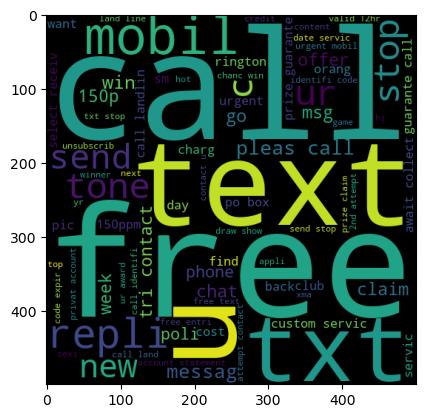

In [176]:
plt.imshow(spam_wc)

In [177]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

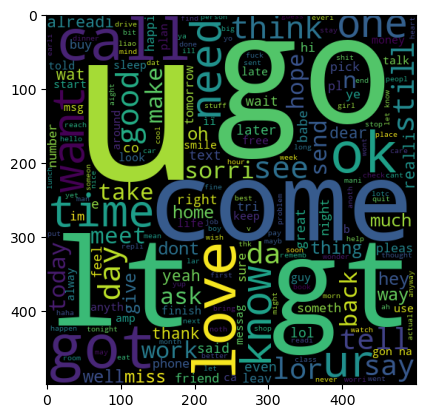

In [178]:
plt.imshow(ham_wc)

In [179]:
# top 30 word of spam
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist(): 
    for word in msg.split(): 
        spam_corpus.append(word)

In [180]:
len(spam_corpus)

9939

<function matplotlib.pyplot.show(close=None, block=None)>

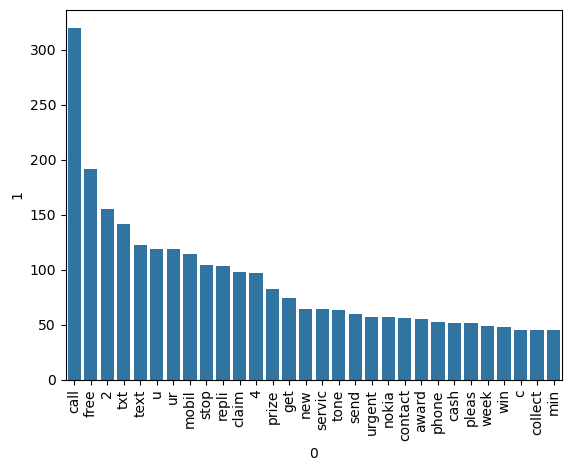

In [181]:
from collections import Counter
sns.barplot(
    x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0], 
    y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1]
)
plt.xticks(rotation='vertical')
plt.show

In [182]:
# top 30 word of ham 
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist(): 
    for word in msg.split(): 
        ham_corpus.append(word)

In [183]:
len(ham_corpus)

35404

<function matplotlib.pyplot.show(close=None, block=None)>

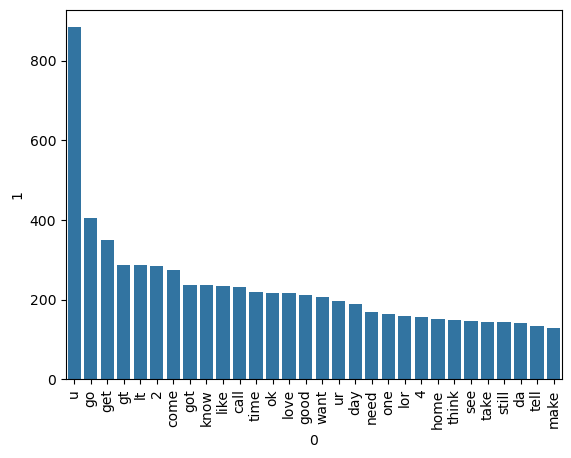

In [184]:
from collections import Counter
sns.barplot(
    x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0], 
    y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1]
)
plt.xticks(rotation='vertical')
plt.show

# Model Building 

In [185]:
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(stop_words='english', max_features=3000, ngram_range=(1,2))

In [186]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [187]:
# appending the num_character column to X 
X = np.hstack((X,df['num_characters'].values.reshape(-1,1)))

In [188]:
from sklearn.preprocessing import MinMaxScaler # not Efficient for model
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [189]:
X.shape

(5169, 3001)

In [190]:
y = df['target'].values

In [191]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [192]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix , precision_score


In [193]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=2)

In [194]:
from sklearn.naive_bayes import GaussianNB , MultinomialNB , BernoulliNB

In [195]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [196]:
gnb.fit(X_train , y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test , y_pred1))
print(confusion_matrix(y_test , y_pred1))
print(precision_score(y_test , y_pred1))

0.8781431334622823
[[784 112]
 [ 14 124]]
0.5254237288135594


In [197]:
mnb.fit(X_train , y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test , y_pred2))
print(confusion_matrix(y_test , y_pred2))
print(precision_score(y_test , y_pred2))

0.9816247582205029
[[894   2]
 [ 17 121]]
0.983739837398374


In [198]:
bnb.fit(X_train , y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test , y_pred3))
print(confusion_matrix(y_test , y_pred3))
print(precision_score(y_test , y_pred3))

0.9806576402321083
[[896   0]
 [ 20 118]]
1.0


In [199]:
# we choosing tfidf (precision score = 100%)

In [200]:
# Import models
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier

In [201]:
# Define individual models
svc = SVC(kernel='sigmoid', gamma=1.0, probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

In [202]:
# Create Voting Classifier
voting = VotingClassifier(
    estimators=[
        ('svm', svc),
        ('nb', mnb),
        ('et', etc)
    ],
    voting='soft'   # use probability-based voting
)

In [203]:
# Train the model
voting.fit(X_train, y_train)

,estimators,"[('svm', ...), ('nb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,1.0
,coef0,0.0


In [206]:
# Predict
y_pred = voting.predict(X_test)

In [207]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))

Accuracy: 0.9825918762088974
Precision: 0.9838709677419355


In [208]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb , open('model.pkl' , 'wb'))